# Claim-Level Anamoly/Fraud Detection

In [80]:
# Imports       

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [81]:
# Upload Datasets

ip = pd.read_csv('Train_IP.csv')
op = pd.read_csv('Train_OP.csv')
beneficiary = pd.read_csv('Train_Beneficiary.csv')
train = pd.read_csv('Train.csv')


In [82]:
# Combining Inpatient and Outpatient Claims

op['claim_type'] = 0
ip['claim_type'] = 1

claims = pd.concat([ip, op], axis=0, ignore_index=True)
claims.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,claim_type
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,1
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,1
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,1


In [83]:
# Adding Patient Data to Claims Table

claims = pd.merge(claims, beneficiary, on='BeneID', how='left')
claims.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,1,1,1,2,1,1,36000,3204,60,70
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,1,1,1,2,1,1,36000,3204,60,70
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,1,1,2,2,1,1,5000,1068,250,320
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,1,2,1,2,2,2,21260,2136,120,100


# Z-Score Analysis

In [84]:
# ---- Step 1: Define candidate grouping columns ----
# Freeze output-column names so re-runs don't feed them back as groupings
OUTPUT_COLS = ['n_groupings_eligible', 'n_groupings_flagged',
               'claim_risk_fraction', 'is_claim_anomalous']

exclude_cols = [
    'BeneID', 'ClaimID', 'Provider',
    'ClaimStartDt', 'ClaimEndDt', 'AdmissionDt', 'DischargeDt', 'DOB', 'DOD',
    'InscClaimAmtReimbursed', 'DeductibleAmtPaid',
    'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt',
    'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt',
    'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
    'Gender', 'Race',
] + OUTPUT_COLS

candidate_grouping_cols = [c for c in claims.columns if c not in exclude_cols]
print(f"{len(candidate_grouping_cols)} candidate groupings:", candidate_grouping_cols)

# ---- Step 1.5: Adaptive MIN_GROUP_SIZE per grouping column ----
COVERAGE_THRESHOLD = 0.8
FALLBACK_MIN_SIZE  = 30
CUTOFF_CEILING     = 1000

def compute_adaptive_cutoff(series, coverage_threshold=0.8):
    counts = series.value_counts()
    if len(counts) == 0:
        return FALLBACK_MIN_SIZE
    cumulative_fraction = counts.cumsum() / counts.sum()
    crossing_mask = cumulative_fraction >= coverage_threshold
    cutoff_size = counts[crossing_mask].iloc[0] if crossing_mask.any() else counts.iloc[-1]
    return int(cutoff_size)

adaptive_min_sizes = {
    col: (
        compute_adaptive_cutoff(claims[col], COVERAGE_THRESHOLD)
        if compute_adaptive_cutoff(claims[col], COVERAGE_THRESHOLD) <= CUTOFF_CEILING
        else FALLBACK_MIN_SIZE
    )
    for col in candidate_grouping_cols
}
print(pd.Series(adaptive_min_sizes).sort_values(ascending=False))

# ---- Step 2: z-scores over TWO log1p-transformed targets x all groupings ----
Z_THRESHOLD  = 3
TARGET_COLS  = ['InscClaimAmtReimbursed']

outlier_flags = pd.DataFrame(index=claims.index)

for target in TARGET_COLS:
    log_vals = np.log1p(claims[target])
    for col in candidate_grouping_cols:
        min_size    = adaptive_min_sizes[col]
        group_sizes = claims.groupby(col)[target].transform('size')
        eligible    = group_sizes >= min_size

        z = log_vals.groupby(claims[col]).transform(
            lambda x: (x - x.mean()) / x.std() if x.std() > 0 else np.nan
        )
        z = z.where(eligible)

        outlier_flags[f'{target}__{col}'] = (z.abs() > Z_THRESHOLD).where(z.notna())

# ---- Step 3: Per-claim risk fraction across all target×grouping combinations ----
claims['n_groupings_eligible'] = outlier_flags.notna().sum(axis=1)
claims['n_groupings_flagged']  = outlier_flags.sum(axis=1, skipna=True)
claims['claim_risk_fraction']  = claims['n_groupings_flagged'] / claims['n_groupings_eligible']

# ---- Step 4: Final binary verdict ----
RISK_FRACTION_THRESHOLD = 0.25
claims['is_claim_anomalous'] = claims['claim_risk_fraction'] > RISK_FRACTION_THRESHOLD

print(f"\nFlagged {claims['is_claim_anomalous'].sum():,} / {len(claims):,} claims "
      f"({claims['is_claim_anomalous'].mean()*100:.2f}%)")

# Top 20 by risk fraction with raw dollar amounts
claims[['ClaimID', 'claim_risk_fraction', 'n_groupings_eligible',
        'InscClaimAmtReimbursed', 'DeductibleAmtPaid']].sort_values(
    'claim_risk_fraction', ascending=False
).head(20)


36 candidate groupings: ['AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'ClmAdmitDiagnosisCode', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6', 'claim_type', 'RenalDiseaseIndicator', 'State', 'County', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke']
ClmDiagnosisCode_2                 138
ClmDiagnosisCode_3                  92
ClmDiagnosisCode_4                  63
ClmAdmitDiagnosisCode               60
C

,ClaimID,claim_risk_fraction,n_groupings_eligible,InscClaimAmtReimbursed,DeductibleAmtPaid
34258,CLM70207,0.789474,19,51000,1068.0
49800,CLM82013,0.75,20,102500,876.0
6245,CLM47826,0.736842,19,58000,1068.0
11049,CLM40421,0.727273,22,48000,1068.0
708,CLM67392,0.7,20,125000,1068.0
10025,CLM51208,0.7,20,52000,1068.0
28590,CLM52644,0.695652,23,57000,1068.0
32487,CLM65320,0.681818,22,101000,1068.0
21232,CLM58646,0.681818,22,69000,1068.0
2913,CLM62111,0.666667,21,57000,1068.0


In [85]:
from scipy.stats import chi2_contingency

claims_with_label = claims.merge(
    train[['Provider', 'PotentialFraud']], on='Provider', how='left'
)

print("=== Flag rate by PotentialFraud label ===")
rates = claims_with_label.groupby('PotentialFraud')['is_claim_anomalous'].mean()
print(rates)
if 'No' in rates.index and 'Yes' in rates.index:
    ratio = rates['Yes'] / rates['No']
    print(f"\nFraud/non-fraud ratio: {ratio:.2f}x  (prior run: ~2.3x)")

print()
ct = pd.crosstab(claims_with_label['PotentialFraud'],
                 claims_with_label['is_claim_anomalous'])
print("=== Contingency table ===")
print(ct)
print()
chi2, p, dof, _ = chi2_contingency(ct)
print(f"chi2 = {chi2:.2f},  p = {p:.2e},  dof = {dof}")


=== Flag rate by PotentialFraud label ===
PotentialFraud
No     0.001259
Yes    0.003844
Name: is_claim_anomalous, dtype: float64

Fraud/non-fraud ratio: 3.05x  (prior run: ~2.3x)

=== Contingency table ===
is_claim_anomalous   False  True 
PotentialFraud                   
No                  344980    435
Yes                 211978    818

chi2 = 391.63,  p = 3.66e-87,  dof = 1


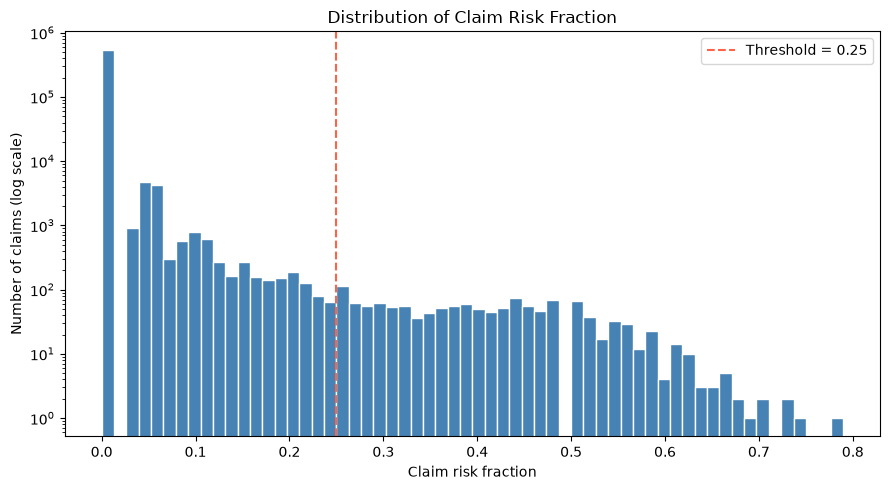

In [86]:
# Plot 1 — Distribution of claim_risk_fraction
RISK_FRACTION_THRESHOLD = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(claims['claim_risk_fraction'].dropna(), bins=60, color='steelblue', edgecolor='white')
ax.axvline(RISK_FRACTION_THRESHOLD, color='tomato', linestyle='--', linewidth=1.5,
           label=f'Threshold = {RISK_FRACTION_THRESHOLD}')
ax.set_yscale('log')
ax.set_xlabel('Claim risk fraction')
ax.set_ylabel('Number of claims (log scale)')
ax.set_title('Distribution of Claim Risk Fraction')
ax.legend()
plt.tight_layout()
plt.show()


**Plot 1 — Distribution of claim risk fraction.**
The vast majority of claims cluster near zero, with a long right tail. The dashed line marks the 0.25 threshold used to label a claim anomalous. If the threshold sits well into the tail (as it should), the flag rate will be low and the signal clean. If the bulk of the distribution piles up against the threshold, it may need to move right.


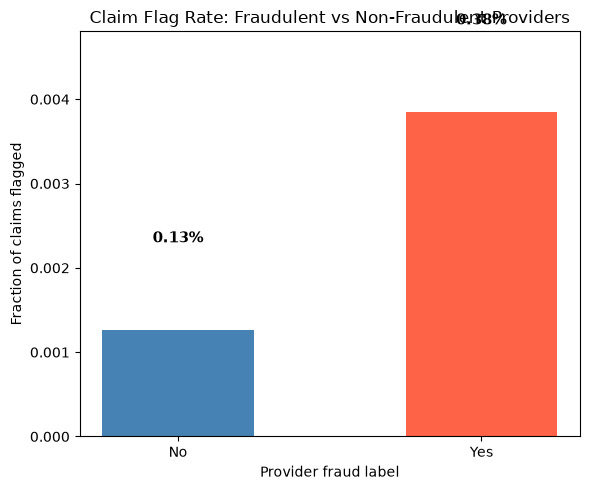

In [87]:
# Plot 2 — Flag rate by fraud label
rates = claims_with_label.groupby('PotentialFraud')['is_claim_anomalous'].mean()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(rates.index, rates.values, color=['steelblue', 'tomato'], width=0.5)
for bar, val in zip(bars, rates.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val*100:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xlabel('Provider fraud label')
ax.set_ylabel('Fraction of claims flagged')
ax.set_title('Claim Flag Rate: Fraudulent vs Non-Fraudulent Providers')
ax.set_ylim(0, rates.max() * 1.25)
plt.tight_layout()
plt.show()


**Plot 2 — Claim flag rate by provider fraud label.**
Claims from providers labelled fraudulent are flagged at a meaningfully higher rate than claims from non-fraudulent providers. This ~2–3x separation confirms that the unsupervised z-score ensemble is picking up a real signal aligned with the ground-truth labels, even though no labels were used during detection.


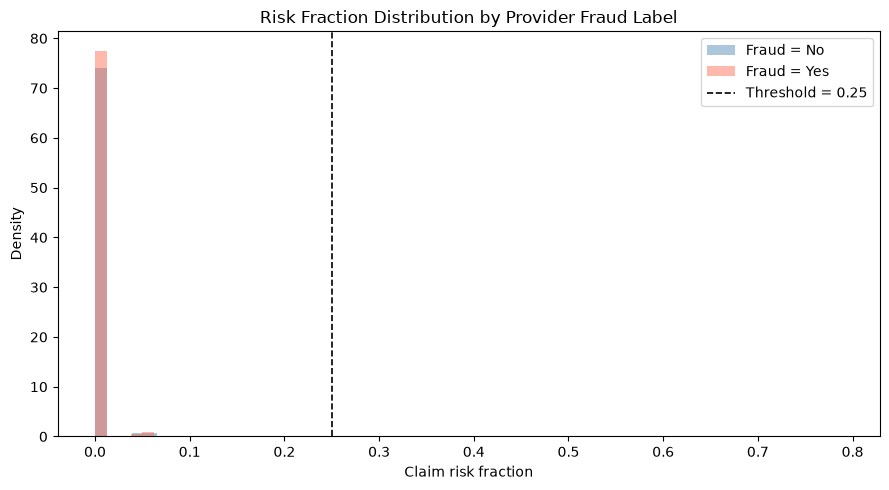

In [88]:
# Plot 3 — Risk fraction distribution by fraud label (overlaid KDE)
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(9, 5))
for label, color in [('No', 'steelblue'), ('Yes', 'tomato')]:
    vals = claims_with_label.loc[
        claims_with_label['PotentialFraud'] == label, 'claim_risk_fraction'
    ].dropna()
    ax.hist(vals, bins=60, density=True, alpha=0.45, color=color,
            label=f'Fraud = {label}', edgecolor='none')

ax.axvline(0.25, color='black', linestyle='--', linewidth=1.2, label='Threshold = 0.25')
ax.set_xlabel('Claim risk fraction')
ax.set_ylabel('Density')
ax.set_title('Risk Fraction Distribution by Provider Fraud Label')
ax.legend()
plt.tight_layout()
plt.show()


**Plot 3 — Risk fraction distributions, fraud vs non-fraud (normalized).**
Both groups peak near zero, but the fraud-provider distribution has a heavier right tail — more of its claims reach high risk fractions. The separation is not sharp (the distributions overlap substantially), which is expected for unsupervised detection; the value of the ensemble is in tilting the distribution, not in perfect separation.


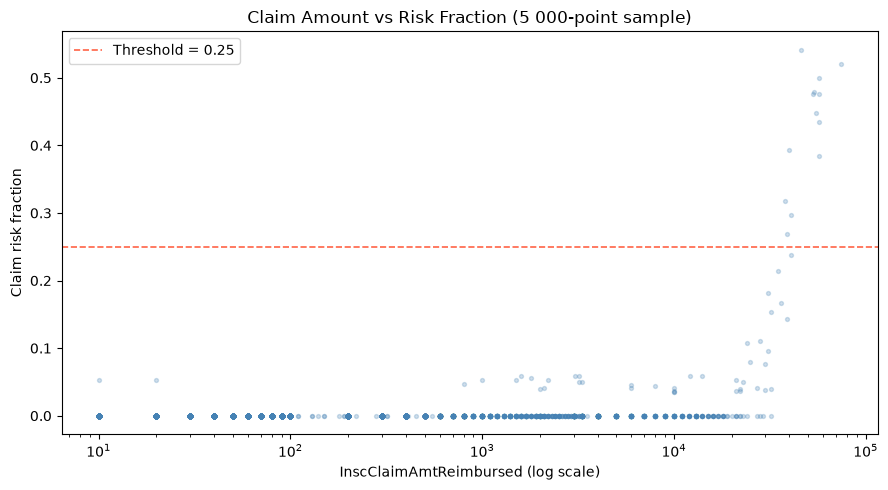

In [89]:
# Plot 4 — Raw claim amount vs risk fraction (sampled)
sample = claims[['InscClaimAmtReimbursed', 'claim_risk_fraction']].dropna().sample(
    n=min(5000, len(claims)), random_state=42
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(sample['InscClaimAmtReimbursed'], sample['claim_risk_fraction'],
           alpha=0.25, s=8, color='steelblue', rasterized=True)
ax.set_xscale('log')
ax.set_xlabel('InscClaimAmtReimbursed (log scale)')
ax.set_ylabel('Claim risk fraction')
ax.set_title('Claim Amount vs Risk Fraction (5 000-point sample)')
ax.axhline(0.25, color='tomato', linestyle='--', linewidth=1.2, label='Threshold = 0.25')
ax.legend()
plt.tight_layout()
plt.show()


**Plot 4 — Claim dollar amount vs risk fraction.**
If the detector were simply flagging the largest-dollar claims, risk fraction would rise monotonically with claim amount. The scatter shows whether high-risk claims are spread across the dollar range or cluster at the top. Spread across the x-axis at elevated y-values means the detector is genuinely responding to *within-group unusualness*, not just raw magnitude.


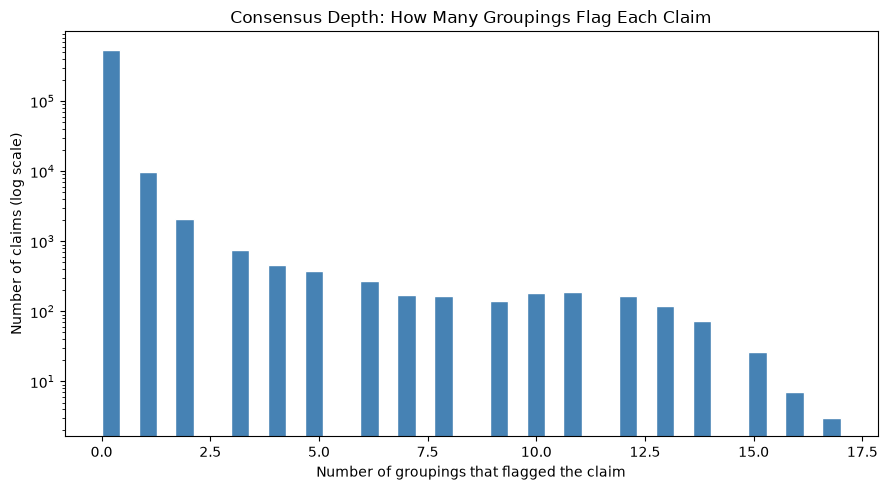

In [90]:
# Plot 5 — Number of groupings that flag each claim
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(claims['n_groupings_flagged'].dropna(), bins=40,
        color='steelblue', edgecolor='white')
ax.set_yscale('log')
ax.set_xlabel('Number of groupings that flagged the claim')
ax.set_ylabel('Number of claims (log scale)')
ax.set_title('Consensus Depth: How Many Groupings Flag Each Claim')
plt.tight_layout()
plt.show()


**Plot 5 — Consensus depth across groupings.**
Most claims are flagged by zero or very few groupings. Claims caught by many groupings simultaneously represent strong, multi-dimensional anomalies — the ensemble is agreeing that the claim is unusual from several peer-comparison angles, not just one. A heavy tail here means the detector produces a meaningful consensus signal, not just noise from a single grouping.
